# Лабораторна робота №1 “Зменшення розмірності даних”

Виконав студент групи КН-42, Пишко Олександр

Мета: ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

## Хід роботи
### 1. Викачати та підготувати дані
* Завантажити датасет за допомогою функції fetch_openml.
* Вивести форму матриці X і кількість унікальних міток у **y**.
* Для попереднього огляду візуалізувати кілька прикладів зображень (наприклад, 10 випадкових цифр) у вигляді 28×28 пікселів.

In [49]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [50]:
import numpy as np
print(f"Form X: {X.shape}")
print(f"Unique points in y: {len(np.unique(y))}")

Form X: (70000, 784)
Unique points in y: 10


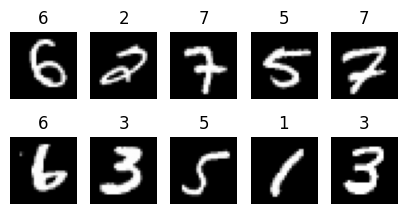

In [51]:
import matplotlib.pyplot as plt

np.random.seed(1)
random_indexes = np.random.choice(X.shape[0], size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(5, 2.5))
axes = axes.ravel()

for i, rand_index in enumerate(random_indexes):
    img = X[rand_index].reshape(28, 28)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(y[rand_index])
    axes[i].axis("off")

### 2. Реалізувати метод головних компонент (PCA)
* Реалізувати PCA із кількістю компонент n_components=3.
* Отримати матрицю проєкцій (X_pca) розміром (70000 × 3);
* Вивести відсоток поясненої дисперсії для кожної компоненти (explained_variance_ratio_).

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print(f"X_pca shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

total_variance = sum(pca.explained_variance_ratio_) * 100
print(f"Saved {total_variance:.2f}% information.")

X_pca shape: (70000, 3)
Explained variance ratio: [0.09746116 0.07155445 0.06149531]
Saved 23.05% information.


## 3. Візуалізувати дані у просторі перших трьох компонент
* Побудувати 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних (використати matplotlib.axes3d або plotly). Точки зафарбувати відповідно до класу цифри.
* Проаналізувати, чи видно кластери для різних цифр, наскільки добре PCA відділяє класи у тривимірному просторі.


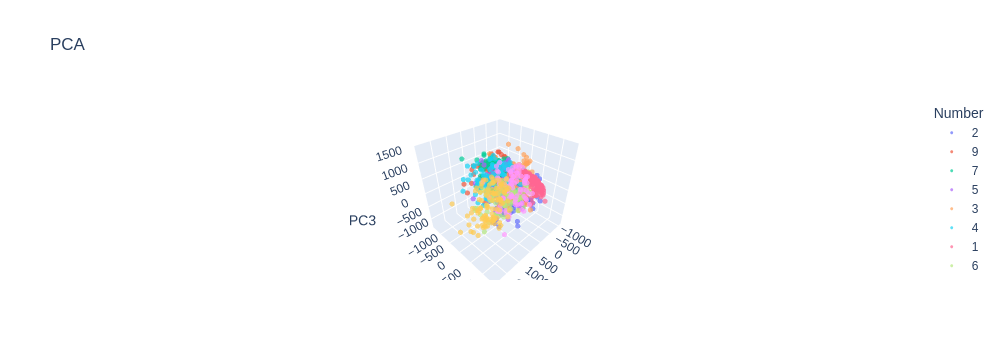

In [70]:
import plotly.express as px

n_samples = 1000
random_indices = np.random.choice(X_pca.shape[0], size=n_samples, replace=False)

X_pca_subset = X_pca[random_indices]
y_subset = y[random_indices].astype(str)

fig = px.scatter_3d(
    x=X_pca_subset[:, 0],
    y=X_pca_subset[:, 1],
    z=X_pca_subset[:, 2],
    color=y_subset,
    color_discrete_sequence=px.colors.qualitative.Plotly,
    title='PCA',
    opacity=0.7,
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Number'}
)

fig.update_traces(marker=dict(size=3))

fig.show()

В ціломи ми можемо побачити нечітку кластеризацію, що очікувано через низький відсоток збереження інформації, тому реконструйовані зображення теж вийдуть не чіткими. Хоча можна помітити, що "1" кластеризувалась достатньо добре, тому ми легко зможемо їх відрізнити від інших цифр.

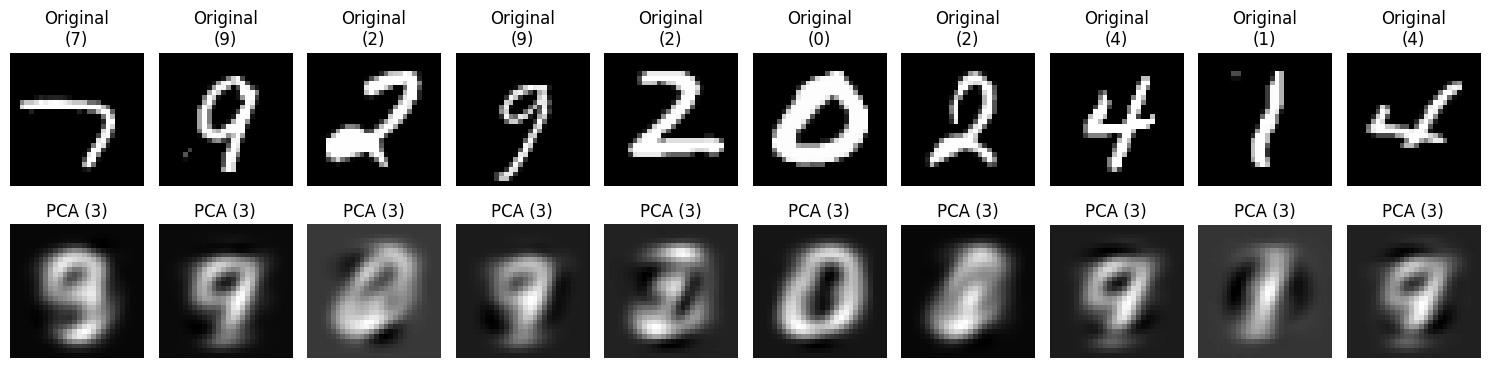

In [71]:
X_reconstructed = pca.inverse_transform(X_pca)

random_indices = np.random.choice(X.shape[0], size=10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, idx in enumerate(random_indices):
    ax_orig = axes[0, i]
    ax_orig.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax_orig.axis('off')
    ax_orig.set_title(f"Original\n({y[idx]})")

    ax_recon = axes[1, i]
    ax_recon.imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
    ax_recon.axis('off')
    ax_recon.set_title("PCA (3)")

plt.tight_layout()
plt.show()

Попереднє припущення збулось, картинки вийшли розмитими. Практично не можливо відрізнити числа "7", "9", "4", хоча "1" виділяється досить сильно.

## 4. Проаналізувати залежність між помилкою реконструкції та кількістю компонент
* Визначити помилку реконструкції (Mean Squared Error, MSE) як середнє квадратів різниці між початковими та реконструйованими значеннями пікселів.
* Обчислити MSE(k) та відсоток поясненої дисперсії для різної кількості компонент k і побудувати відповідні графіки.

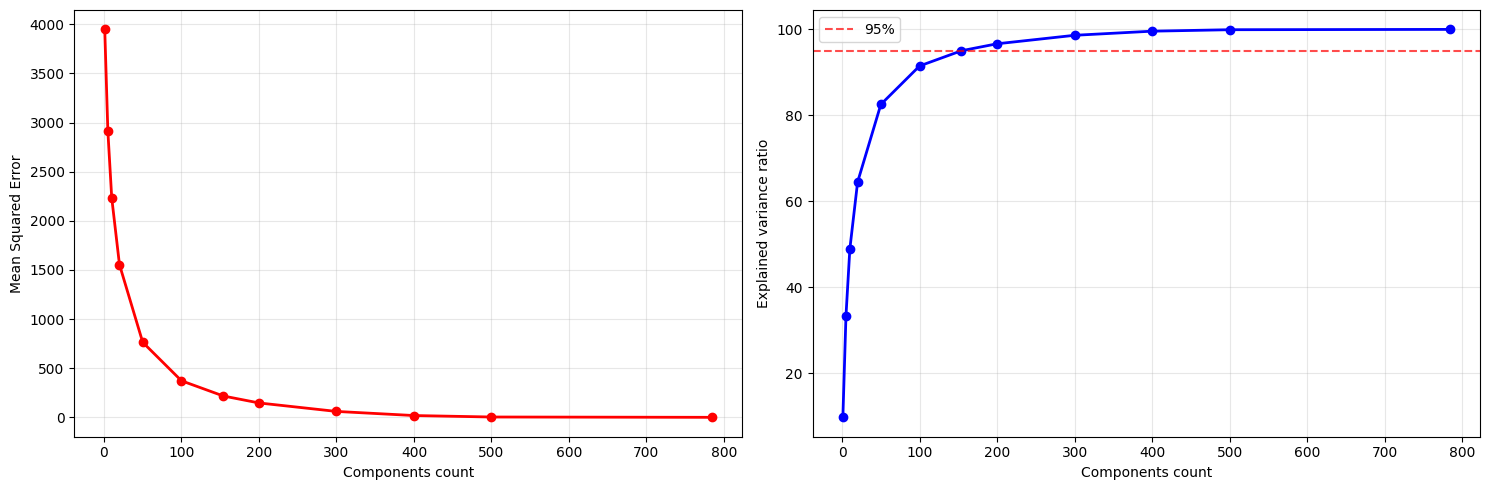

In [79]:
k_values = [1, 5, 10, 20, 50, 100, 154, 200, 300, 400, 500, 784]
mse_list = []
explained_variances = []

pca_full = PCA(n_components=784)
X_pca_full = pca_full.fit_transform(X)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

for k in k_values:
    explained_variances.append(cumulative_variance[k-1] * 100)
    X_reconstructed_k = np.dot(X_pca_full[:, :k], pca_full.components_[:k, :]) + pca_full.mean_
    
    mse = np.mean((X - X_reconstructed_k) ** 2)
    mse_list.append(mse)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_values, mse_list, 'ro-', linewidth=2, markersize=6)
ax1.set_xlabel('Components count')
ax1.set_ylabel('Mean Squared Error')
ax1.grid(True, alpha=0.3)

ax2.plot(k_values, explained_variances, 'bo-', linewidth=2, markersize=6)
ax2.axhline(y=95, color='r', linestyle='--', alpha=0.7, label='95%')
ax2.set_xlabel('Components count')
ax2.set_ylabel('Explained variance ratio')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Можемо побачити, що для досягнення збереження даних 95% нам потрібно хоча би 200 головних компонент